In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Chargement des données
df = pd.read_csv("cve_anssi_enriched.csv")

# Nettoyage rapide
df = df.dropna(subset=["cvss", "epss"])
df = df[df["cvss"] != "Non disponible"]
df = df[df["epss"] != "Non disponible"]
df["cvss"] = df["cvss"].astype(float)
df["epss"] = df["epss"].astype(float)

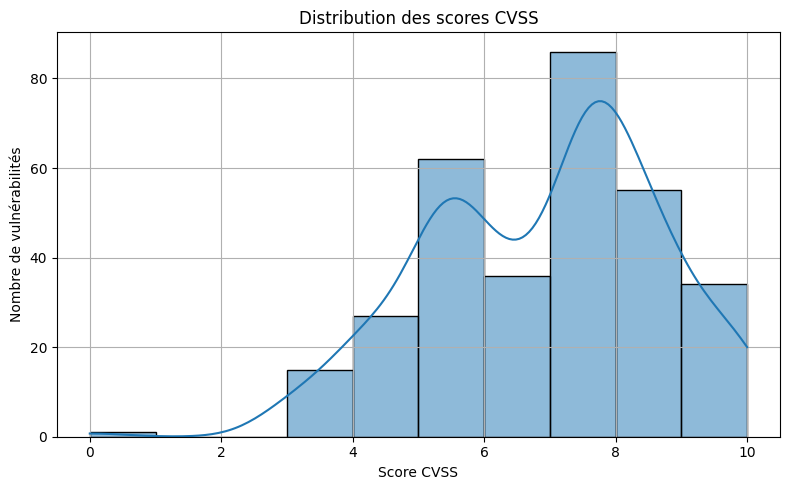

In [22]:
# Histogramme des scores CVSS
plt.figure(figsize=(8, 5))
sns.histplot(df["cvss"], bins=10, kde=True)
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.grid(True)
plt.tight_layout()
#plt.savefig("cvss_distribution.png")
plt.show()

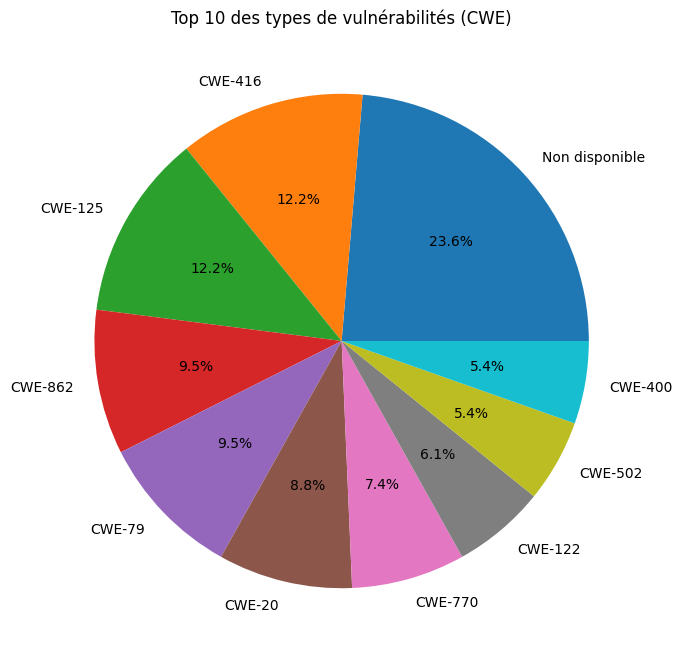

In [23]:
# Diagramme circulaire des types CWE
top_cwe = df["cwe"].value_counts().head(10)
plt.figure(figsize=(7, 7))
top_cwe.plot.pie(autopct="%1.1f%%")
plt.title("Top 10 des types de vulnérabilités (CWE)")
plt.ylabel("")
plt.tight_layout()
#plt.savefig("cwe_pie.png")
plt.show()

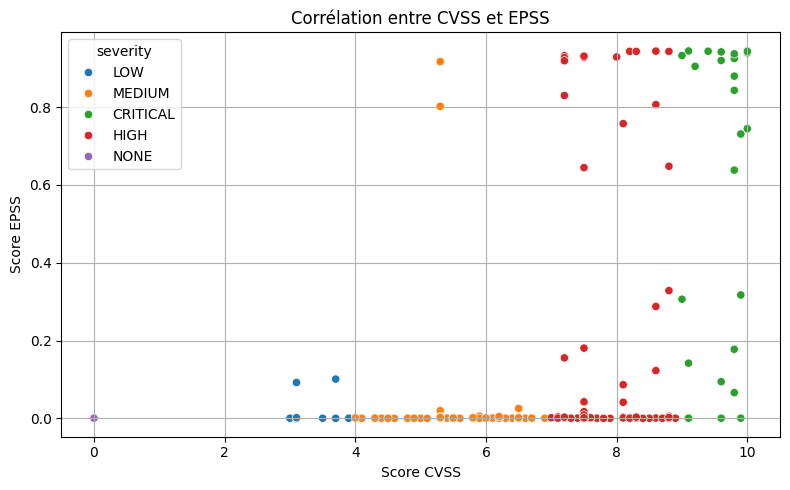

In [24]:
# Nuage de points CVSS vs EPSS
plt.figure(figsize=(8, 5))
sns.scatterplot(x="cvss", y="epss", data=df, hue="severity")
plt.title("Corrélation entre CVSS et EPSS")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.grid(True)
plt.tight_layout()
#plt.savefig("scatter_cvss_epss.png")
plt.show()

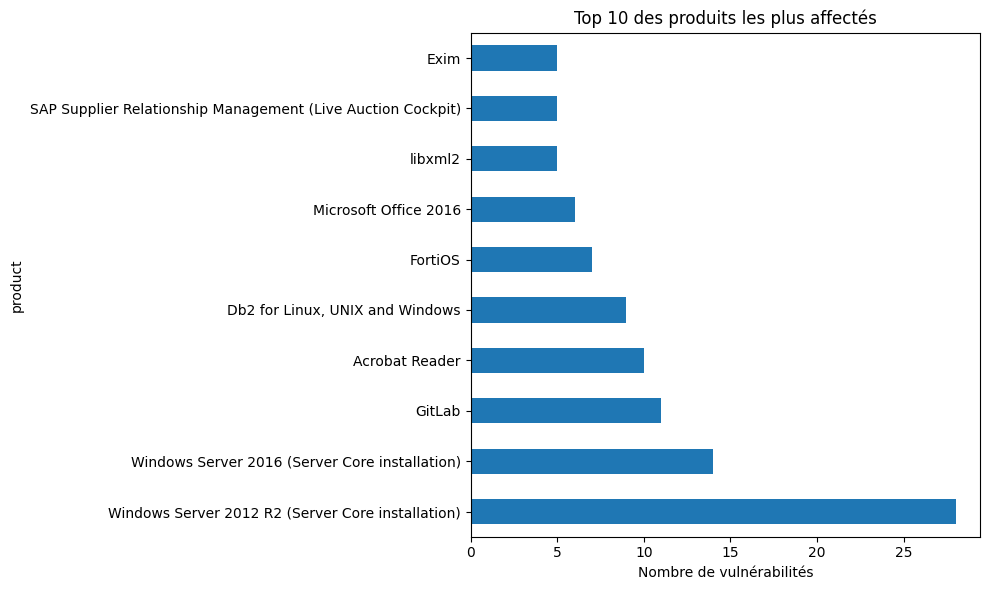

In [25]:
# Produits les plus affectés
plt.figure(figsize=(10, 6))
df["product"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 des produits les plus affectés")
plt.xlabel("Nombre de vulnérabilités")
plt.tight_layout()
#plt.savefig("top_products.png")
plt.show()

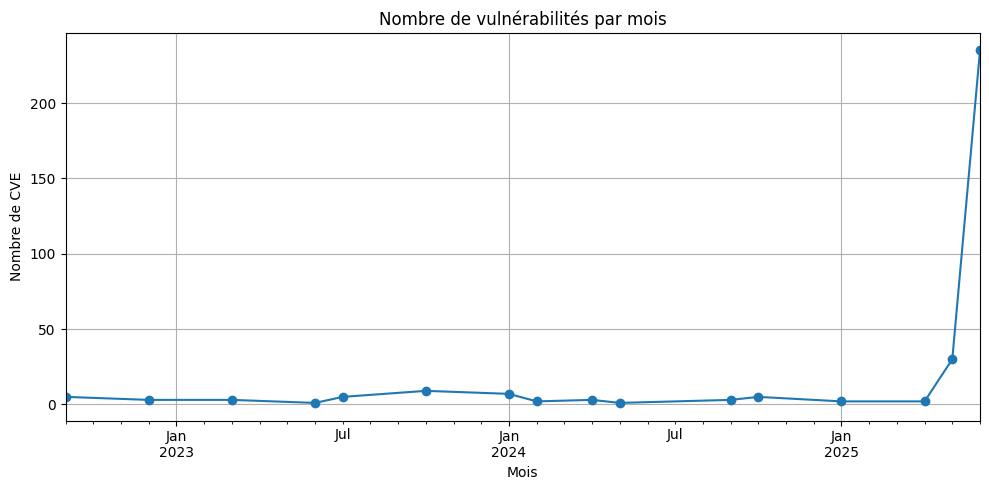

In [26]:
# Évolution temporelle
df["date"] = pd.to_datetime(df["date"])
df_by_month = df.groupby(df["date"].dt.to_period("M")).size()
df_by_month.plot(kind="line", marker="o", figsize=(10, 5))
plt.title("Nombre de vulnérabilités par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de CVE")
plt.grid(True)
plt.tight_layout()
#plt.savefig("timeline.png")
plt.show()

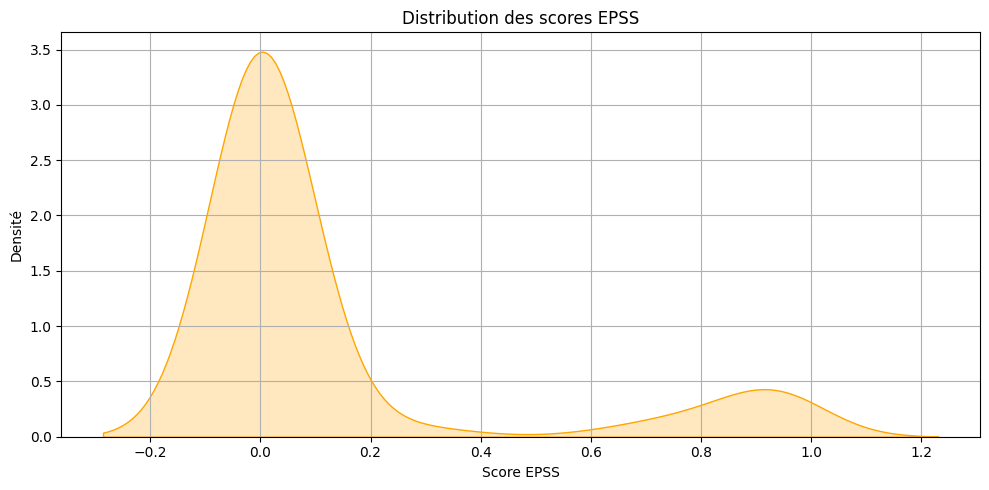

In [27]:
# Courbe des scores EPSS
plt.figure(figsize=(10, 5))
sns.kdeplot(df["epss"], fill=True, color="orange")
plt.title("Distribution des scores EPSS")
plt.xlabel("Score EPSS")
plt.ylabel("Densité")
plt.grid(True)
plt.tight_layout()
#plt.savefig("epss_curve.png")
plt.show()

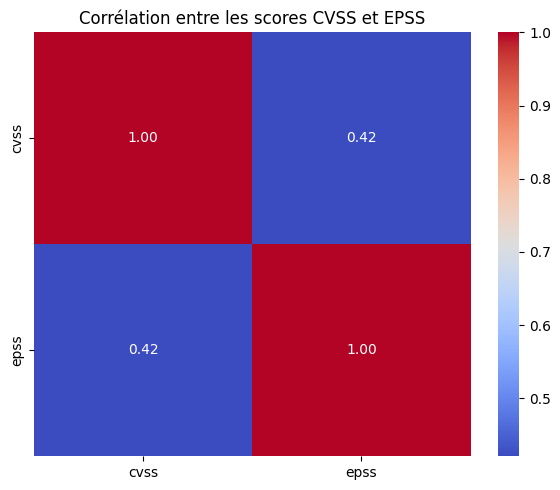

In [28]:
# Heatmap corrélation CVSS / EPSS
plt.figure(figsize=(6, 5))
corr = df[["cvss", "epss"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélation entre les scores CVSS et EPSS")
plt.tight_layout()
#plt.savefig("heatmap_cvss_epss.png")
plt.show()

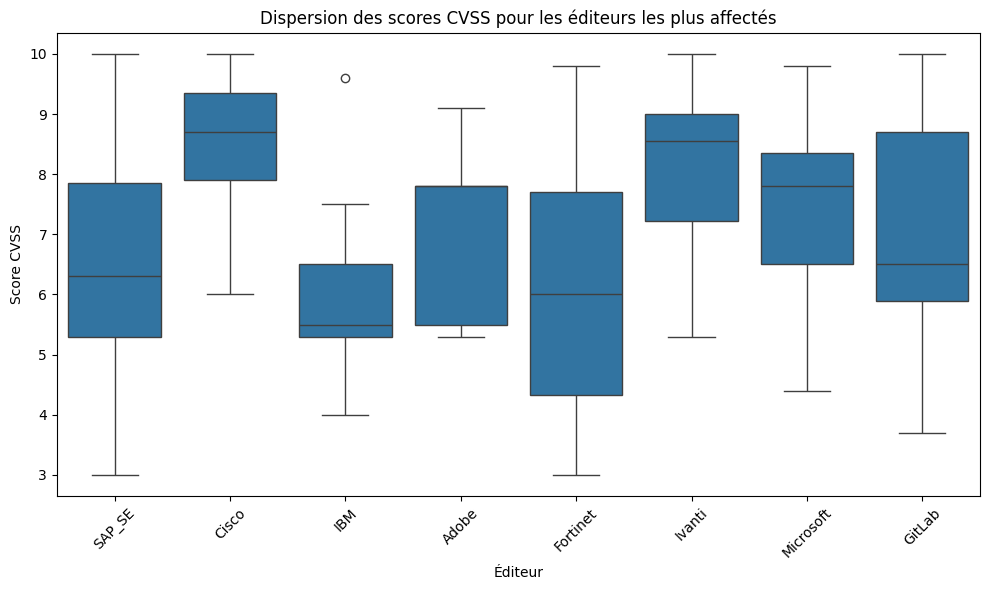

In [29]:
# Boxplot CVSS par éditeur
top_vendors = df["vendor"].value_counts().head(8).index
df_top_vendors = df[df["vendor"].isin(top_vendors)]

plt.figure(figsize=(10, 6))
sns.boxplot(x="vendor", y="cvss", data=df_top_vendors)
plt.title("Dispersion des scores CVSS pour les éditeurs les plus affectés")
plt.xlabel("Éditeur")
plt.ylabel("Score CVSS")
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig("boxplot_cvss_vendor.png")
plt.show()

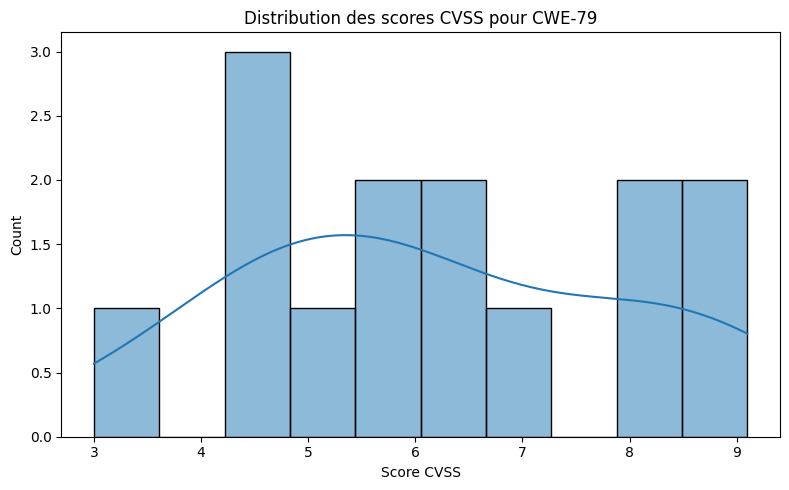

In [30]:
# Visualisation spécifique pour un type CWE
type_cwe = "CWE-79"  # Exemple : Cross Site Scripting
df_cwe = df[df["cwe"] == type_cwe]

plt.figure(figsize=(8, 5))
sns.histplot(df_cwe["cvss"], bins=10, kde=True)
plt.title(f"Distribution des scores CVSS pour {type_cwe}")
plt.xlabel("Score CVSS")
plt.tight_layout()
#plt.savefig(f"cvss_distribution_{type_cwe}.png")
plt.show()

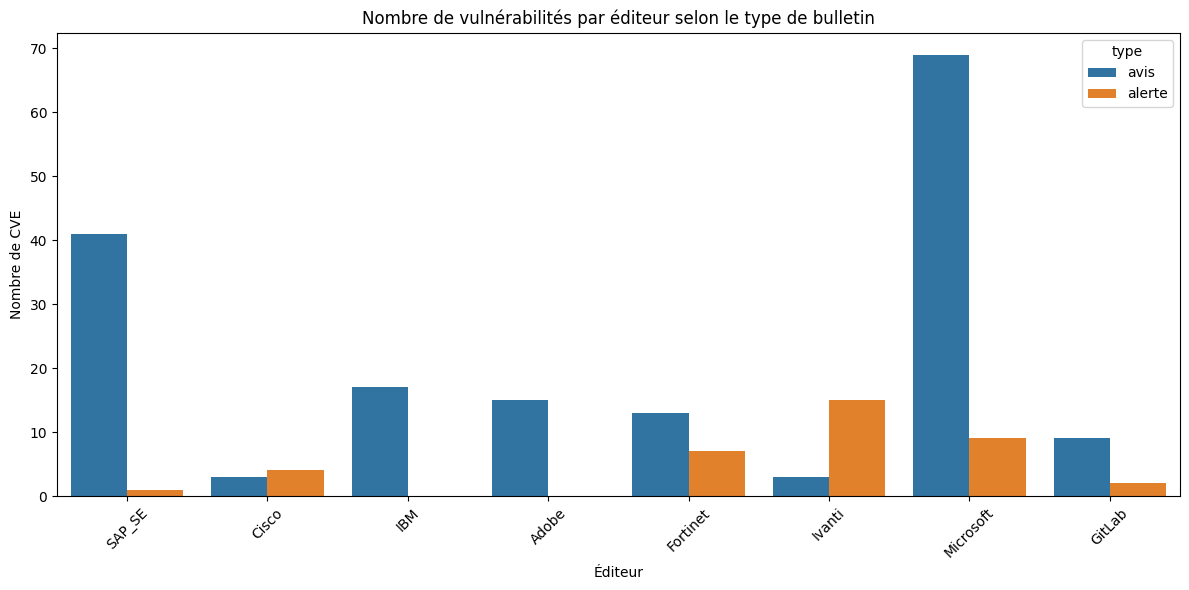

In [31]:
# Nombre de vulnérabilités par éditeur et type de bulletin
plt.figure(figsize=(12, 6))
sns.countplot(x="vendor", hue="type", data=df[df["vendor"].isin(top_vendors)])
plt.title("Nombre de vulnérabilités par éditeur selon le type de bulletin")
plt.xlabel("Éditeur")
plt.ylabel("Nombre de CVE")
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig("vendor_bulletin_type.png")
plt.show()

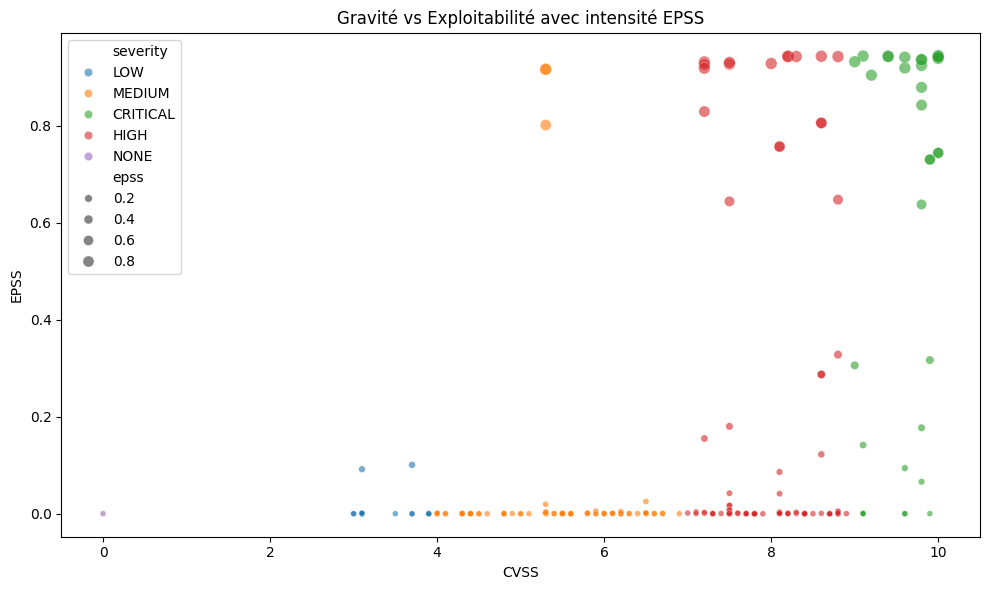

In [32]:
# Nuage de points avec intensité EPSS
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="cvss", y="epss", size="epss", hue="severity", alpha=0.6)
plt.title("Gravité vs Exploitabilité avec intensité EPSS")
plt.xlabel("CVSS")
plt.ylabel("EPSS")
plt.tight_layout()
#plt.savefig("scatter_cvss_epss_severity.png")
plt.show()

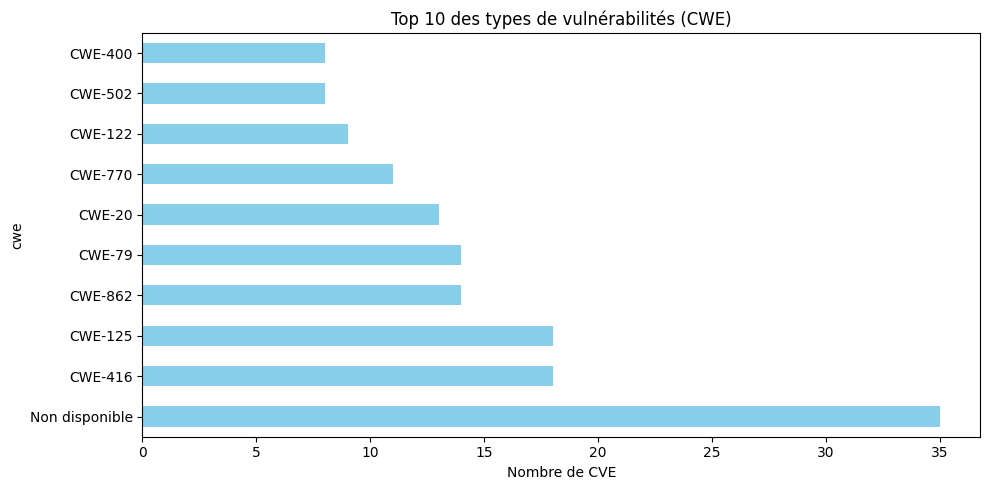

In [33]:
# Top CWE les plus fréquents
top_cwe = df["cwe"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_cwe.plot(kind="barh", color="skyblue")
plt.title("Top 10 des types de vulnérabilités (CWE)")
plt.xlabel("Nombre de CVE")
plt.tight_layout()
#plt.savefig("top_cwe.png")
plt.show()

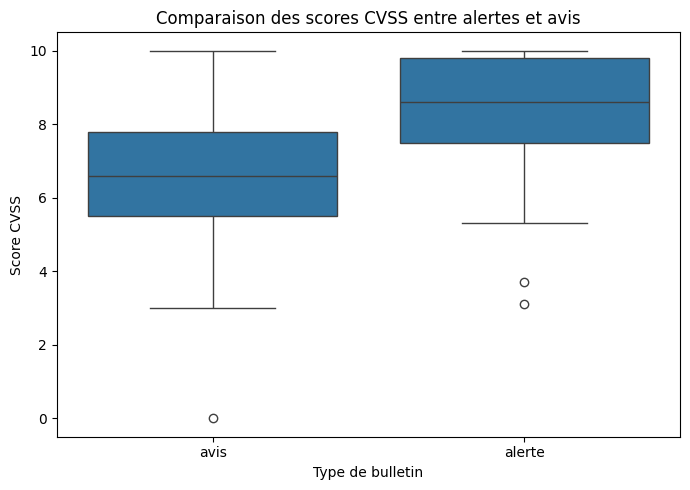

In [34]:
# Score CVSS moyen par type de bulletin
plt.figure(figsize=(7, 5))
sns.boxplot(x="type", y="cvss", data=df)
plt.title("Comparaison des scores CVSS entre alertes et avis")
plt.xlabel("Type de bulletin")
plt.ylabel("Score CVSS")
plt.tight_layout()
#plt.savefig("cvss_bulletin_type.png")
plt.show()